# The POLONAISE UHDM data release

**Private.** A guided tour of `release/luhdm_datarelease_v3.h5` — the single,
self-describing HDF5 file that every other notebook in this repository now reads
from. Notebooks 01–05 no longer recompute any physics inline; they open this
file through the convenience loader and pull slices out of it, so a notebook run
and a cluster run cannot drift.

**What is inside.** The analysis is stored as a matrix over
$(\text{sensor mode},\ \alpha_n,\ m_\text{DM},\ \lambda)$:

- `/atm` — the exclusion cube **with** atmospheric attenuation: optimum-interval
  `extremeness` (the confidence $p\in[0,1]$), expected counts `mu`, mode-less
  `n_transit`, and a per-mode `status` code, shaped
  $(\text{mode},\alpha_n,m_\text{DM},\lambda)$.
- `/noatm` — the same cube with the atmosphere switched **off** (finer mass axis).
- `/halo` — the transit geometry (`n_transit`, reach `bmax`) on the flux-map grid.
- `/detector` — the observed candidate lists, the reconstructed blips, and the
  detection efficiency $\varepsilon(q)$ per mode.
- `/reference_curves` — production-fidelity arrival-speed $f(v)$ and raw spectra
  $\mathrm{d}R/\mathrm{d}q$ per mediator range (the curves behind notebook 02).

**Two ways in.**

1. **Raw HDF5.** The file is plain HDF5 with Dimension Scales and rich
   `units`/`description` attributes on every dataset, so `h5py`, `h5ls`,
   `h5dump`, MATLAB — any HDF5 tool — opens it with *no luhdm code at all*. This
   notebook shows the raw route side-by-side with the loader to prove it.
2. **The `luhdm.release` loader.** A thin convenience layer: eager axis loading,
   exact/nearest index resolution, hyperslab plane reads, and the shared
   best-mass criterion.

The full schema table (path | shape | dtype | units | description), the
$\lambda$-grid recipe, and the `status`-code enum live in
[`release/README.md`](../release/README.md).

In [1]:
%matplotlib inline
import h5py
import numpy as np
import matplotlib.pyplot as plt

from luhdm import release

rel = release.open_release()          # opens release/luhdm_datarelease_v3.h5
print(rel)
print(rel.tree())

<Release ~/code/luhdm/release/luhdm_datarelease_v3.h5 (v3.0-m0p356mg-bcap10cm)>
/
  atm/
    extremeness  (3, 44, 119, 55) float32  [1]
    mu  (3, 44, 119, 55) float32  [counts]
    n_transit  (44, 119, 55) float32  [counts]
    status  (3, 44, 119, 55) uint8  [enum]
  axes/
    alpha_halo_n  (64,) float64  [1]
    alpha_n  (44,) float64  [1]
    lambda_m  (55,) float64  [m]
    m_phi_gev  (55,) float64  [GeV]
    mass_gev  (119,) float64  [GeV]
    mass_halo_gev  (64,) float64  [GeV]
    mass_noatm_gev  (600,) float64  [GeV]
    mode  (3,) uint8  [1]
  detector/
    all_blips_mode1  (66,) float64  [eV]
    all_blips_mode2  (99,) float64  [eV]
    all_blips_mode3  (443,) float64  [eV]
    eff_1_df2  (400,) float64  [1]
    eff_1_df3  (400,) float64  [1]
    eff_2_df2  (400,) float64  [1]
    eff_2_df3  (400,) float64  [1]
    eff_3_df2  (400,) float64  [1]
    eff_3_df3  (400,) float64  [1]
    events_mode1  (66,) float64  [GeV]
    events_mode2  (99,) float64  [GeV]
    events_mode3 

In [2]:
# The SAME listing with raw h5py — no luhdm code, just the HDF5 library.
# Every dataset carries a `units` attribute; f.visititems walks the whole tree.
def show(name, obj):
    if isinstance(obj, h5py.Dataset):
        units = obj.attrs.get("units", "")
        print(f"{name:34s} {str(obj.shape):18s} {str(obj.dtype):8s} [{units}]")

with h5py.File(release.DEFAULT_PATH, "r") as f:
    f.visititems(show)

atm/extremeness                    (3, 44, 119, 55)   float32  [1]
atm/mu                             (3, 44, 119, 55)   float32  [counts]
atm/n_transit                      (44, 119, 55)      float32  [counts]
atm/status                         (3, 44, 119, 55)   uint8    [enum]
axes/alpha_halo_n                  (64,)              float64  [1]
axes/alpha_n                       (44,)              float64  [1]
axes/lambda_m                      (55,)              float64  [m]
axes/m_phi_gev                     (55,)              float64  [GeV]
axes/mass_gev                      (119,)             float64  [GeV]
axes/mass_halo_gev                 (64,)              float64  [GeV]
axes/mass_noatm_gev                (600,)             float64  [GeV]
axes/mode                          (3,)               uint8    [1]
detector/all_blips_mode1           (66,)              float64  [eV]
detector/all_blips_mode2           (99,)              float64  [eV]
detector/all_blips_mode3           (443

## Provenance is baked into the root attributes

These attributes fully specify the computation: the RNG `seed`, the `git_commit`
of the code that produced the file, the detector fiducials
($q_\text{thresh}$, $R_\text{eff}$, $f_X$, …), the live-time `t_exposure_s`, the
fidelity parameters, and the exact package versions. Anyone can audit or
regenerate the release from these alone — nothing is hidden in a script.

In [3]:
for k, v in sorted(rel.attrs.items()):
    print(f"{k:28s} {v}")

b_constrained_max_m          0.1
confidence_recommended       0.95
created                      2026-07-30T07:35:16.934076+00:00
df                           3
f_x                          0.1
fid_json                     {"n_ode": 400, "n_shm": 300000, "n_q": 240, "q_span": 30000.0, "n_mc": 10000}
fid_n_mc                     10000
fid_n_ode                    400
fid_n_q                      240
fid_n_shm                    300000
fid_q_span                   30000.0
file_format                  luhdm-datarelease
git_commit                   8752d41b7d26a0dbb5cc882bc6fd2c8f586fbee9
git_dirty                    False
m_planck_gev                 1.22e+19
n_neutrons                   1.0658682634730539e+20
packages_json                {"numpy": "2.5.0", "scipy": "1.18.0", "h5py": "3.16.0", "optimum_interval": "0.2.0", "luhdm": "0.1.0", "matplotlib": "3.11.0", "pandas": "3.0.3", "python": "3.14.6"}
pkg_h5py                     3.16.0
pkg_luhdm                    0.1.0
pkg_matplotlib    

## Axes and the massless convention

Datasets use axis order **(mode, $\alpha_n$, $m_\text{DM}$, $\lambda$)**. The
$\lambda$ axis is the finite mediator ranges in ascending order, followed by
`np.inf` as the **last** element — the massless / analytic slice, for which the
mediator mass $m_\phi$ is exactly `0.0`.

The seven canonical tags (`2m`, `2cm`, …, `2um`) are **exact** members of the
$\lambda$ axis, so a "tag figure" is just an integer slice — no interpolation.
Index resolution reflects this: `at_lambda` demands an **exact** match (a value
off the axis raises `KeyError` with the three nearest), while `at_mass` and
`at_alpha` snap to the **nearest** grid point in $\log_{10}$.

In [4]:
ax = rel.axes
print("alpha_n :", ax.alpha_n.size, "points",
      f"[{ax.alpha_n[0]:.1e} .. {ax.alpha_n[-1]:.1e}]")
print("mass_gev:", ax.mass_gev.size, "points",
      f"[{ax.mass_gev[0]:.1e} .. {ax.mass_gev[-1]:.1e}] GeV")
print("lambda_m:", ax.lambda_m.size, "points",
      f"({ax.n_finite} finite + massless)")
print("lambda_m =", ax.lambda_m)
print()

# the massless convention: inf is the LAST lambda element, m_phi there is 0
print("lambda_m[-1] is inf                 :", np.isinf(ax.lambda_m[-1]))
print("at_lambda('massless') == last index :",
      rel.at_lambda("massless"), "==", ax.lambda_m.size - 1)
print("m_phi_gev at the massless slice     :", ax.m_phi_gev[-1])
print("at_lambda('200um')                  :", rel.at_lambda("200um"))
# tags are EXACT axis members (not nearest-snapped):
print("lambda_m[at_lambda('20um')] == 2e-5 :",
      ax.lambda_m[rel.at_lambda("20um")] == 2e-5)

alpha_n : 44 points [1.0e-10 .. 1.0e+00]
mass_gev: 119 points [1.0e+05 .. 1.2e+19] GeV
lambda_m: 55 points (54 finite + massless)
lambda_m = [1.00000000e-07 1.46532008e-07 2.14716293e-07 3.14628094e-07
 4.61030863e-07 6.75557779e-07 1.00000000e-06 1.25915510e-06
 1.58547158e-06 1.99635463e-06 2.00000000e-06 2.51372012e-06
 3.16516352e-06 3.98543181e-06 4.56378313e-06 5.01827680e-06
 6.31878886e-06 7.95633524e-06 1.00000000e-05 1.00182601e-05
 1.26145434e-05 1.43589439e-05 1.58836667e-05 2.00000000e-05
 3.08309920e-05 4.51772715e-05 6.61991630e-05 9.70029626e-05
 1.42140389e-04 2.00000000e-04 3.05198572e-04 4.47213595e-04
 6.55311060e-04 9.60240452e-04 1.40705961e-03 2.00000000e-03
 3.02118624e-03 4.42700484e-03 6.48697908e-03 9.50550068e-03
 1.39286010e-02 2.00000000e-02 2.99069756e-02 4.38232918e-02
 6.42151493e-02 9.40957475e-02 1.37880388e-01 2.02038900e-01
 2.96051657e-01 4.33810437e-01 6.35671142e-01 9.31461686e-01
 1.36488951e+00 2.00000000e+00            inf]

lambda_m[-1] is in

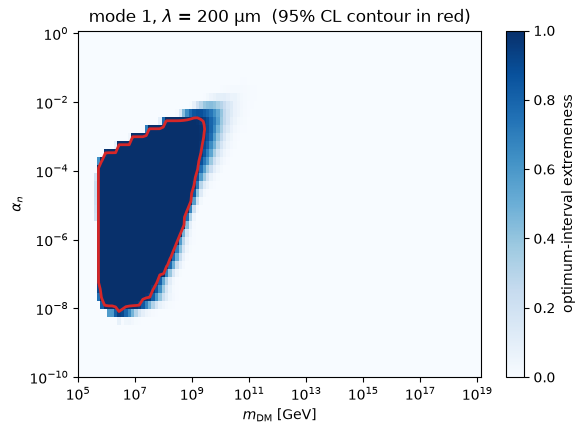

In [5]:
# Hello, world: a single exclusion slice in ~10 lines.
P = rel.mass_plane("extremeness", mode=1, lam="200um")     # (n_alpha, n_mass)
ax = rel.axes
fig, a = plt.subplots(figsize=(6.5, 4.5))
mesh = a.pcolormesh(ax.mass_gev, ax.alpha_n, P, cmap="Blues",
                    vmin=0, vmax=1, shading="auto")
a.contour(ax.mass_gev, ax.alpha_n, P, levels=[0.95], colors="#d62728", linewidths=2)
a.set_xscale("log"); a.set_yscale("log")
a.set_xlabel(r"$m_{\rm DM}$ [GeV]"); a.set_ylabel(r"$\alpha_n$")
a.set_title(r"mode 1, $\lambda$ = 200 µm  (95% CL contour in red)")
fig.colorbar(mesh, ax=a, label="optimum-interval extremeness")
plt.show()

## The exclusion boundary is a level set

At a fixed mass and range the 95% CL exclusion is simply the set of couplings
where $p \ge 0.95$ along the $\alpha_n$ column. `excluded_alpha_band` returns the
(lo, hi) coupling edges as log-interpolated crossings of that level, or
`(nan, nan)` if nothing is excluded. Below we get it three ways:

1. straight from the loader,
2. **by hand** from the raw HDF5 column — to demystify what the loader does,
3. again at 90% confidence, to show that any confidence level is just a
   different level set of the *same* surface.

In [6]:
MASS, LAM, MODE = 1e8, "200um", 1

# 1) straight from the loader
lo, hi = rel.excluded_alpha_band(mass=MASS, lam=LAM, mode=MODE)
print(f"loader  95% CL : alpha_n in [{lo:.3e}, {hi:.3e}]")

# 2) the same BY HAND from the raw HDF5 column (only the tag->lambda map is luhdm's)
with h5py.File(release.DEFAULT_PATH, "r") as f:
    mode_ax = f["axes"]["mode"][:]
    alpha   = f["axes"]["alpha_n"][:]
    mass_ax = f["axes"]["mass_gev"][:]
    lam_ax  = f["axes"]["lambda_m"][:]
    imode = int(np.where(mode_ax == MODE)[0][0])
    im = int(np.argmin(np.abs(np.log10(mass_ax) - np.log10(MASS))))  # nearest mass in log10
    il = int(np.argmin(np.abs(lam_ax - 2e-4)))                       # lambda = 200 um (exact)
    column = f["atm"]["extremeness"][imode, :, im, il]               # p(alpha_n)

def band(alpha, p, level):
    """log-interpolated (lo, hi) crossings of `level` — what excluded_alpha_band does."""
    idx = np.where(p >= level)[0]
    if idx.size == 0:
        return np.nan, np.nan
    lo = (np.log10(alpha[0]) if idx[0] == 0
          else np.interp(level, p[idx[0]-1:idx[0]+1], np.log10(alpha[idx[0]-1:idx[0]+1])))
    hi = (np.log10(alpha[-1]) if idx[-1] == len(p) - 1
          else np.interp(-level, -p[idx[-1]:idx[-1]+2], np.log10(alpha[idx[-1]:idx[-1]+2])))
    return 10 ** lo, 10 ** hi

lo_h, hi_h = band(alpha, column, 0.95)
print(f"by hand 95% CL : alpha_n in [{lo_h:.3e}, {hi_h:.3e}]   (matches the loader)")

# 3) any CL is just another level set of the same p-surface
lo90, hi90 = rel.excluded_alpha_band(mass=MASS, lam=LAM, mode=MODE, confidence=0.90)
print(f"loader  90% CL : alpha_n in [{lo90:.3e}, {hi90:.3e}]")

loader  95% CL : alpha_n in [9.956e-08, 1.825e-03]
by hand 95% CL : alpha_n in [9.956e-08, 1.825e-03]   (matches the loader)
loader  90% CL : alpha_n in [9.395e-08, 2.056e-03]


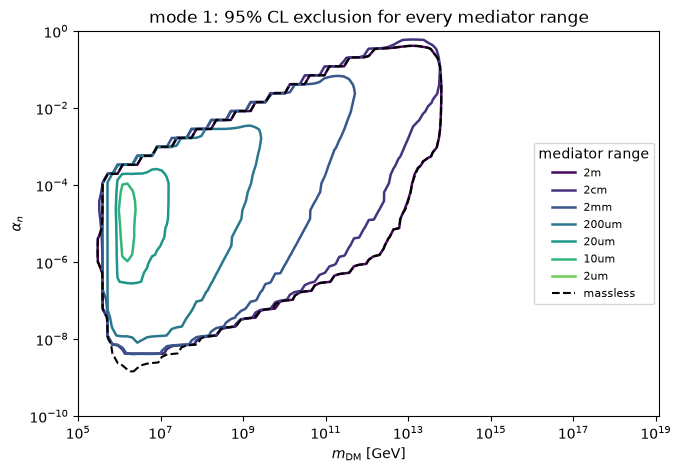

In [7]:
# Reproduce notebook 01's "all mediator ranges" figure from scratch, from the release.
from luhdm.release import TAG_ORDER      # ['2m','2cm','2mm','200um','20um','10um','2um']
ax = rel.axes
colors = plt.cm.viridis(np.linspace(0.02, 0.78, len(TAG_ORDER)))
fig, a = plt.subplots(figsize=(7.5, 5))
for tag, c in zip(TAG_ORDER, colors):                        # loop the 7 finite tags ...
    P = rel.mass_plane("extremeness", mode=1, lam=tag)
    if (P >= 0.95).any():
        a.contour(ax.mass_gev, ax.alpha_n, P, levels=[0.95], colors=[c], linewidths=1.8)
    a.plot([], [], color=c, lw=1.8, label=tag)
Pm = rel.mass_plane("extremeness", mode=1, lam="massless")   # ... plus the analytic slice
a.contour(ax.mass_gev, ax.alpha_n, Pm, levels=[0.95], colors="k", linestyles="--")
a.plot([], [], color="k", ls="--", label="massless")
a.set_xscale("log"); a.set_yscale("log")
a.set_xlabel(r"$m_{\rm DM}$ [GeV]"); a.set_ylabel(r"$\alpha_n$")
a.legend(loc="center right", fontsize=8, title="mediator range")
a.set_title("mode 1: 95% CL exclusion for every mediator range")
plt.show()
# ~13 lines of plotting logic loop 8 tags and reproduce the notebook-01 figure.

## Dumping a single cell

`rel.cell(mass, alpha, lam, mode)` returns a full dump of one cube cell: the atm
`extremeness`/`mu`/`n_transit`/`status`, plus the nearest `/halo` geometry
(`bmax`, `n_transit_halo`). Remember the nearest-cell semantics — **mass** and
**alpha** snap to the nearest grid point in $\log_{10}$, but **lambda** must
match a tag/axis value exactly. The `resolved` values it prints back are the
grid points actually used, which need not equal what you asked for.

The `status` code records how $p$ was obtained: `0` ok (MC), `1` exception
(value is NaN), `2` $\mu<0.2$ shortcut ($p\equiv0$), `3` $\mu>40$ shortcut
($p\equiv1$), `4` no spectrum support ($\mu=0$).

In [8]:
EXAMPLE = dict(mass=1e8, alpha=1e-3, lam="200um", mode=1)
info = rel.cell(**EXAMPLE)
print("requested:", EXAMPLE)
print("resolved cell (nearest-in-log10 for mass/alpha, exact for lambda):")
for k, v in info.items():
    print(f"  {k:16s} {v}")

requested: {'mass': 100000000.0, 'alpha': 0.001, 'lam': '200um', 'mode': 1}
resolved cell (nearest-in-log10 for mass/alpha, exact for lambda):
  mass_gev         96471330.72266711
  alpha_n          0.0009478599776522384
  lambda_m         0.0002
  indices          (30, 25, 29)
  extremeness      1.0
  mu               295.8273620605469
  n_transit        1501.2156982421875
  status           3
  bmax             0.0027313425671309233
  n_transit_halo   3614.43603515625


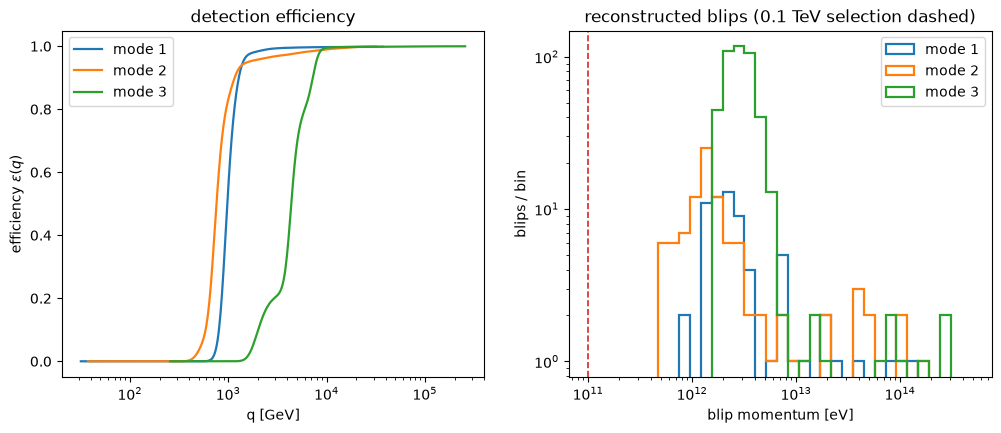

mode 1:   66 candidates above threshold,   66 blips total
mode 2:   99 candidates above threshold,   99 blips total
mode 3:  443 candidates above threshold,  443 blips total


In [9]:
# Detector data straight from the release — a compressed reprise of notebook 00.
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.5))

# left: detection efficiency epsilon(q) for the three modes (df=3 hypothesis)
for mode in (1, 2, 3):
    q, eff = rel.efficiency_curve(mode)              # q in GeV
    a0.plot(q, eff, lw=1.6, label=f"mode {mode}")
a0.set_xscale("log")
a0.set_xlabel("q [GeV]"); a0.set_ylabel(r"efficiency $\varepsilon(q)$")
a0.set_title("detection efficiency"); a0.legend()

# right: all reconstructed blips (eV); the 0.1 TeV selection in red
Q_TH_EV = 0.1e12                                     # 0.1 TeV = 1e11 eV
allb = np.concatenate([rel.all_blips(m) for m in (1, 2, 3)])
bins = np.logspace(np.log10(allb.min()), np.log10(allb.max()), 30)
for mode in (1, 2, 3):
    a1.hist(rel.all_blips(mode), bins=bins, histtype="step", lw=1.6, label=f"mode {mode}")
a1.axvline(Q_TH_EV, color="#d62728", ls="--", lw=1.2)
a1.set_xscale("log"); a1.set_yscale("log")
a1.set_xlabel("blip momentum [eV]"); a1.set_ylabel("blips / bin")
a1.set_title("reconstructed blips (0.1 TeV selection dashed)"); a1.legend()
plt.show()

for mode in (1, 2, 3):
    print(f"mode {mode}: {rel.events(mode).size:4d} candidates above threshold, "
          f"{rel.all_blips(mode).size:4d} blips total")

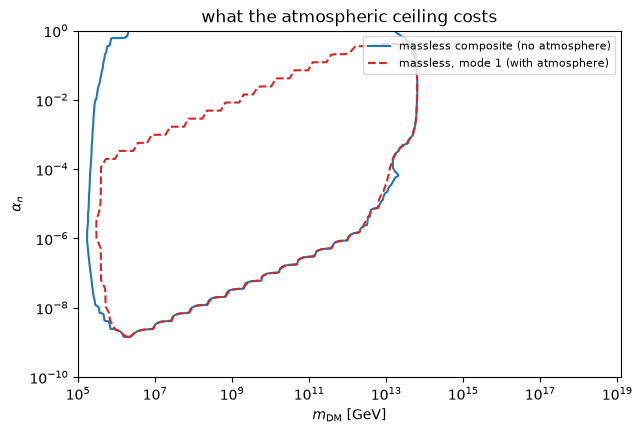

In [10]:
# Composite teaser: what the atmospheric ceiling costs, in two lines of loading.
noatm = rel.composite("extremeness", lam="massless", group="noatm")    # 3-mode max, atmosphere off
atm1  = rel.mass_plane("extremeness", mode=1, lam="massless", group="atm")  # mode 1, atmosphere on
axn = rel.axes_noatm

fig, a = plt.subplots(figsize=(7, 4.5))
a.contour(axn.mass_gev, axn.alpha_n, noatm, levels=[0.95], colors="#1f77b4")
a.contour(rel.axes.mass_gev, rel.axes.alpha_n, atm1, levels=[0.95],
          colors="#d62728", linestyles="--")
a.plot([], [], color="#1f77b4", label="massless composite (no atmosphere)")
a.plot([], [], color="#d62728", ls="--", label="massless, mode 1 (with atmosphere)")
a.set_xscale("log"); a.set_yscale("log")
a.set_xlabel(r"$m_{\rm DM}$ [GeV]"); a.set_ylabel(r"$\alpha_n$")
a.set_title("what the atmospheric ceiling costs")
a.legend(fontsize=8)
plt.show()

## How it was built, verifying it, and citing it

**Build pipeline.** The cube is produced in two stages:
`scripts/build_release.py` runs one per-$\lambda$ shard at a time on a many-core
node (all randomness pinned to a single `seed`), and `scripts/assemble_release.py`
merges the shards into `release/luhdm_datarelease_v3.h5`, computes the reference
curves, and writes `release/provenance.json` (the merged per-run records plus the
assembly metadata) and `release/SHA256SUMS`.

**Verify the download.** From the repository root:

```bash
sha256sum -c release/SHA256SUMS
```

**Citation.** *POLONAISE UHDM data release v3* — DOI `<Zenodo placeholder>`.
Cite the release DOI alongside the analysis paper `<paper placeholder>`.

**What the numbers mean.** The stored `extremeness` is a frequentist
optimum-interval confidence: $p \ge C$ at a point is the statement that this
$(m_\text{DM}, \alpha_n, \lambda)$ is **excluded at confidence $C$** by the
observed candidates. No background model is assumed. Unmodelled backgrounds can
only *weaken* an exclusion — they can never fake one — so the excluded regions
are conservative: the true limits are at least this strong.

In [11]:
rel.close()
# A plain open + close is fine in a notebook. Scripts should prefer the context
# manager, which closes the file even if an exception is raised mid-analysis:
#
#     with release.open_release() as rel:
#         P = rel.mass_plane("extremeness", mode=1, lam="200um")
#         ...  # file is closed automatically on the way out
print("release file closed")

release file closed
